In [7]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import datetime
import pytz

NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
LDN_tz = pytz.timezone("Europe/London") 
UTC_tz = pytz.timezone("UTC") 

import sys
sys.path.append("../../")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
from Query.IRSwaps.IRSwapQuery import IRSwapQuery 
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from Query.IRSwaps.IRSwapValue import IRSwapValue

(<Figure size 1200x800 with 1 Axes>,
 <Axes: >,
  <matplotlib.lines.Line2D at 0x2db26ac5090>])

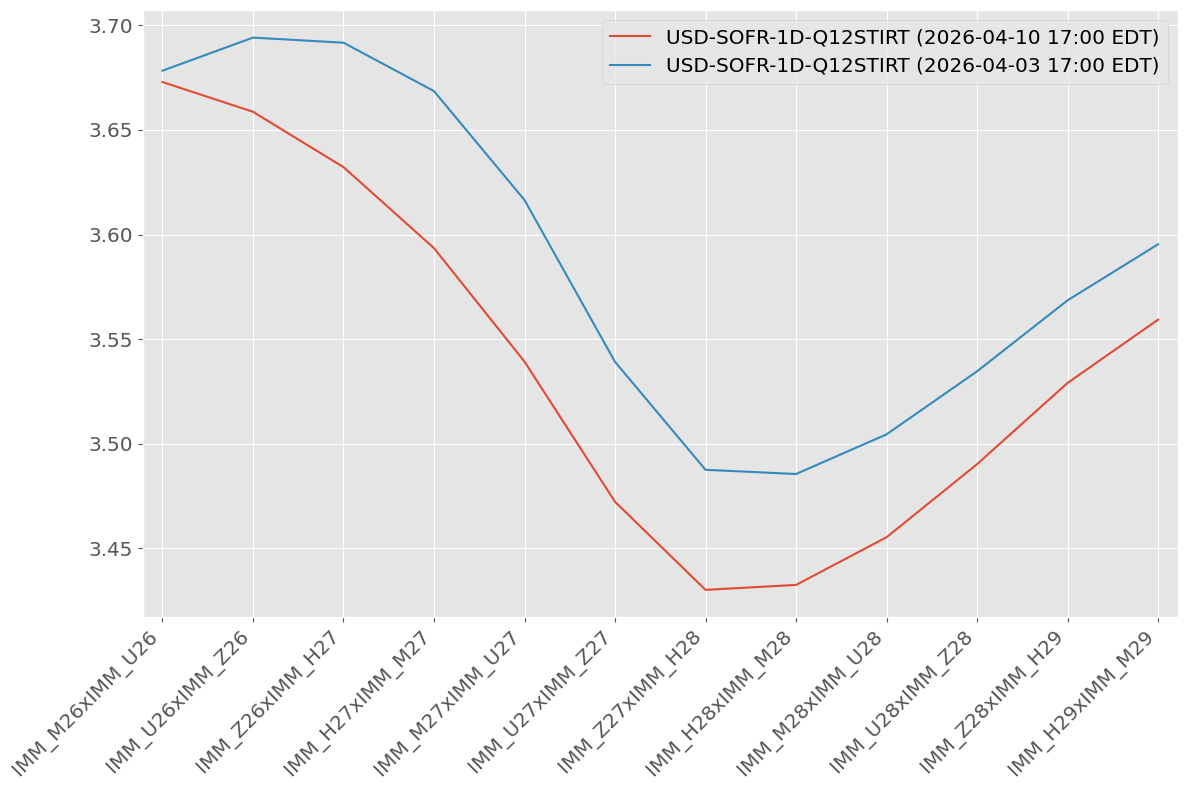

In [9]:
from MDP.IRSwaps.BARCHART_STIRF.rl import BARCHART_STIRF_CURVE, plot_overnight_forward_curves

bc_stirf_curve = BARCHART_STIRF_CURVE()

plot_overnight_forward_curves(
	quarterly_imm_forwards=True,
	curves=[
		# bc_stirf_curve.build_curve(
		# 	curve_name="USD-OIS-Q12xM12STIRT-SERFFX",
		# 	timestamp=NY_tz.localize(datetime.datetime(2026, 3, 11, 17, 00)),
		# 	# kwargs={"force_refresh": True, "cache_full_intraday_fetch": True},

		# ),
		bc_stirf_curve.build_curve(
			curve_name="USD-SOFR-1D-Q12STIRT",
			# curve_name="CAD-CORRA-Q8STIRT",
			# timestamp="live",
			timestamp=NY_tz.localize(datetime.datetime(2026, 4, 10, 17, 00)),
		),
        bc_stirf_curve.build_curve(
			curve_name="USD-SOFR-1D-Q12STIRT",
			# curve_name="CAD-CORRA-Q8STIRT",
			timestamp=NY_tz.localize(datetime.datetime(2026, 4, 3, 17, 00)),
		),
		# bc_stirf_curve.build_curve(
		# 	curve_name="CAD-CORRA-Q8STIRT",
		# 	timestamp="live",
		# ),
        # bc_stirf_curve.build_curve(
		# 	# curve_name="USD-OIS-Q12xM12STIRT-SERFFX",
		# 	curve_name="USD-SOFR-1D-Q12STIRT",
		# 	timestamp=NY_tz.localize(datetime.datetime(2025, 8, 1,  17, 00)),
		# 	# kwargs={"force_refresh": True, "cache_full_intraday_fetch": True},
		# ),
        # bc_stirf_curve.build_curve(
		# 	curve_name="USD-OIS-Q12xM12STIRT-SERFFX-MIX23",
			# timestamp=NY_tz.localize(datetime.datetime(2026, 3, 11, 17, 00)),
		# 	# kwargs={"force_refresh": True, "cache_full_intraday_fetch": True},

		# ),
		# bc_stirf_curve.build_curve(
		# 	curve_name="USD-OIS-Q12xM12STIRT-SERFFX-MIX23",
		# 	# timestamp=NY_tz.localize(datetime.datetime(2026, 3, 12, 17, 00)),
		# 	timestamp="live",
		# 	# kwargs={"force_refresh": True, "cache_full_intraday_fetch": True},
		# ),
		# bc_stirf_curve.build_curve(
		# 	curve_name="USD-SOFR-1D-Q12STIRT",
		# 	timestamp=NY_tz.localize(datetime.datetime(2023, 3, 10, 17, 00)),
		# ),
	]
)

In [8]:
curve_mdp = IRSwapsMDP(source="BARCHART_STIRF-RL")
cad_curve_handle = curve_mdp._get_curve(curve_name="CAD-CORRA-Q8STIRT", timestamp="live")
usd_curve_handle = curve_mdp._get_curve(curve_name="USD-SOFR-1D-Q12STIRT", timestamp="live")

In [13]:
risk = 100_000
cad_query = IRSwapQuery(curve="CAD-CORRA-Q8STIRT", tenor="IMM_Z26xIMM_H27", structure_kwargs={"bpv": risk}).resolve_query("live", pricer_or_curve=cad_curve_handle)
cad_pkg, cad_rws = cad_query.resolve_package(pricer_or_curve=cad_curve_handle)
cad_vmap = cad_query.build_value_map(pricer_or_curve=cad_curve_handle, package=cad_pkg, risk_weights=cad_rws)

usd_query = IRSwapQuery(curve="USD-SOFR-1D-Q12STIRT", tenor="IMM_Z26xIMM_H27", structure_kwargs={"bpv": risk}).resolve_query("live", pricer_or_curve=usd_curve_handle)
usd_pkg, usd_rws = usd_query.resolve_package(pricer_or_curve=usd_curve_handle)
usd_vmap = usd_query.build_value_map(pricer_or_curve=usd_curve_handle, package=usd_pkg, risk_weights=usd_rws)

(usd_vmap.apply(value=IRSwapValue.RATE) - cad_vmap.apply(value=IRSwapValue.RATE)) * 100

76.6608184611449

In [ ]:
""